In [1]:
!pip install botorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 738.3/738.3 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.7/277.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import torch.nn as nn
import math
import warnings
from botorch.models.gpytorch import GPyTorchModel
from botorch.acquisition import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.test_functions import Branin
from gpytorch.distributions import MultivariateNormal

# Matplotlib for plotting (optional)
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

# Set default tensor type
torch.set_default_dtype(torch.float64)

# --- 1. Kernel Function (Required by TPRTFullBatch) ---
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the Radial Basis Function (RBF) kernel between two sets of points.
    """
    # Ensure lengthscale and variance are tensors
    if not isinstance(lengthscale, torch.Tensor):
        lengthscale = torch.tensor(lengthscale)
    if not isinstance(variance, torch.Tensor):
        variance = torch.tensor(variance)

    # Expand dimensions for broadcasting
    X1_ = X1 / lengthscale
    X2_ = X2 / lengthscale

    # Compute squared distances
    dist_sq = torch.cdist(X1_, X2_, p=2).pow(2)

    return variance * torch.exp(-0.5 * dist_sq)


# --- 2. User-Provided TPRTFullBatch Class ---
class TPRTFullBatch:
    """
    Implementation of the full (non-sparse) Student-t Process regression model.
    This version is aligned with the structure of the SparseTPRTFullBatch class.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):

        self.X = X
        self.y = y.view(-1, 1) # Ensure y is always of shape (N, 1)
        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))

        # --- Variational Parameters (updated via CAVI) ---
        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)
        self.L_f = torch.eye(self.N, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.alpha_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)
        self.beta_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma_sq": torch.exp(self.log_likelihood_sigma_sq),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }

    def _update_q_lambda(self, params):
        """CAVI update for q(lambda_i). Receives params as an argument."""
        S_f = self.L_f @ self.L_f.T
        var_f = S_f.diag().unsqueeze(1)
        expected_f_mean = self.m_f

        self.alpha_lambda = params['nu_e'] / 2.0 + 0.5
        expected_sq_error = (self.y - expected_f_mean).pow(2) + var_f
        self.beta_lambda = params['nu_e'] / 2.0 + (1.0 / (2.0 * params['sigma_sq'])) * expected_sq_error

    def _update_q_r(self, params, Lxx):
        """CAVI update for q(r). Receives params and Lxx as arguments."""
        S_f = self.L_f @ self.L_f.T

        trace_term = torch.trace(torch.cholesky_solve(S_f, Lxx))
        mean_term = self.m_f.T @ torch.cholesky_solve(self.m_f, Lxx)
        expected_f_quadratic_form = trace_term + mean_term

        self.alpha_r = params['nu_f'] / 2.0 + self.N / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_f_quadratic_form.squeeze()

    def _update_q_f(self, params, Lxx):
        """CAVI update for q(f). Receives params and Lxx as arguments."""
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda

        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = expected_r * Kxx_inv + torch.diag(expected_lambda.squeeze() / params['sigma_sq'])

        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N, device=self.X.device), L_f_inv, upper=False)[0]

        temp_vec = (expected_lambda / params['sigma_sq']) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, params, Lxx):
        """
        Wrapper for a single CAVI update cycle.
        """
        self._update_q_lambda(params)
        self._update_q_r(params, Lxx)
        self._update_q_f(params, Lxx)

    def _e_step(self, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Performs the E-Step by running CAVI updates.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            for _ in range(cavi_max_iter):
                m_f_prev = self.m_f.clone()
                self._cavi_step(params, Lxx)
                m_f_rel_change = torch.norm(self.m_f - m_f_prev) / (torch.norm(m_f_prev) + 1e-8)
                if m_f_rel_change < cavi_tol:
                    break

    def _m_step(self, optimizer):
        """Performs the M-Step by updating hyperparameters."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, cavi_tol=1e-5, lr=0.01, verbose=False):
        """Fits the model using the Variational EM algorithm."""
        optimizer = torch.optim.Adam([
            self.log_kernel_lengthscale, self.log_kernel_variance,
            self.log_likelihood_sigma_sq, self.log_nu_f, self.log_nu_e
        ], lr=lr)

        elbo_history = []
        if verbose:
            print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)

            if verbose and (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")

        if verbose:
            print("\nOptimization finished.")
        return elbo_history

    def _calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        """
        params = self._get_hyperparams()
        Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
        Lxx = torch.linalg.cholesky(Kxx)
        S_f = self.L_f @ self.L_f.T

        # 1. Expected Log Likelihood
        E_q_f = self.m_f
        Var_q_f = S_f.diag().unsqueeze(1)
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        e_log_lik = -0.5 * self.N * math.log(2 * math.pi) - 0.5 * self.N * torch.log(params['sigma_sq']) + \
                      0.5 * torch.sum(E_log_lambda) - \
                      0.5 / params['sigma_sq'] * torch.sum(E_lambda * expected_sq_error)

        # 2. KL Divergence for f and r
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        log_q_f = -torch.sum(torch.log(torch.diag(self.L_f)))
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r
        trace_term = torch.trace(torch.cholesky_solve(S_f, Lxx))
        quad_form_term = self.m_f.T @ torch.cholesky_solve(self.m_f, Lxx)
        E_quad_form_f = trace_term + quad_form_term
        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * log_det_Kxx + 0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        E_log_p_r = p_alpha_r * torch.log(p_beta_r) - torch.lgamma(p_alpha_r) + \
                    (p_alpha_r - 1) * E_log_r - p_beta_r * E_r
        kl_f_r_grouped = (log_q_f + log_q_r) - (E_log_p_f_r + E_log_p_r)

        # 3. KL Divergence for lambda_i
        p_alpha_lambda, p_beta_lambda = params['nu_e'] / 2.0, params['nu_e'] / 2.0
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(p_alpha_lambda) - p_alpha_lambda * torch.log(p_beta_lambda)) - \
                    (self.alpha_lambda - p_alpha_lambda) * E_log_lambda + \
                    (self.beta_lambda - p_beta_lambda) * E_lambda
        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_f_r_grouped - kl_lambda_sum
        return elbo

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            params = self._get_hyperparams()
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()
            Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)

            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()

            # Stabilize the calculation of E_inv_r
            E_inv_r = self.beta_r / (self.alpha_r - 1.0).clamp(min=1e-6)
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            pred_nu = 2 * self.alpha_r

            return pred_mean, pred_var.unsqueeze(1), pred_nu


# --- 3. BoTorch Wrapper for the TPRT Model ---
class TPRTBoTorchModel(GPyTorchModel):
    """
    A BoTorch-compatible wrapper for the TPRTFullBatch model.
    """
    def __init__(self, train_X, train_Y, **kwargs):
        super().__init__()
        self._num_outputs = train_Y.shape[-1]
        self.model = TPRTFullBatch(X=train_X, y=train_Y, **kwargs)

        # Fit the internal TPRT model upon initialization
        self.model.fit(max_iter_global=50, cavi_max_iter=15, lr=0.05, verbose=False)

    @property
    def num_outputs(self) -> int:
        return self._num_outputs

    def forward(self, x: torch.Tensor):
        """
        BoTorch's forward pass. It expects a MultivariateNormal distribution.

        Args:
            x: A `(q, batch_shape, d)`-dim tensor of test points.

        Returns:
            A `MultivariateNormal` object with predictive mean and covariance.
        """
        # Reshape x for the predict method, which expects (n, d)
        # Original shape: (q, batch_shape, d) or (q, d)
        # We need to flatten it to (q * batch_shape, d)
        x_reshaped = x.view(-1, self.model.D)

        # Get predictions from the underlying TPRT model
        mean, var, _ = self.model.predict(x_reshaped)

        # Reshape mean and variance back to BoTorch's expected format
        # Mean: (batch_shape, q, m)
        # Covariance: (batch_shape, q, m, m)
        # Here m=1 (single output)
        target_shape = x.shape[:-1] + torch.Size([self.num_outputs])
        mean = mean.view(target_shape)

        # Ensure variance is non-negative
        var = var.clamp(min=1e-9)
        covar = torch.diag_embed(var.view(target_shape))

        return MultivariateNormal(mean, covar)

# --- 4. Bayesian Optimization Setup ---

# Define the problem
problem = Branin()
bounds = problem.bounds
DIM = problem.dim

# Optimization parameters
N_INIT = 5  # Number of initial random points
N_ITERATIONS = 20 # Number of optimization iterations
BATCH_SIZE = 1 # Number of points to evaluate at each iteration

print(f"Optimizing {type(problem).__name__} function ({DIM} dimensions)")
print(f"True minimum: {problem.optimal_value:.4f}")
print("-" * 50)

# Generate initial training data
train_X = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(N_INIT, DIM)
train_Y = problem(train_X).unsqueeze(-1) # Branin is a minimization problem, BoTorch maximizes

# Keep track of the best value found so far
best_value_found = train_Y.min().item()
print(f"Initial best value: {best_value_found:.4f}")

# Store results for plotting
all_X = [train_X]
all_Y = [train_Y]
best_values = [best_value_found]

# --- 5. The Optimization Loop ---
for i in range(N_ITERATIONS):
    # 1. Initialize and fit the BoTorch model wrapper
    model = TPRTBoTorchModel(train_X, train_Y)

    # 2. Define the acquisition function (LogNoisyExpectedImprovement)
    # We use LogNEI because our model provides predictive distributions (it's a noisy EI variant)
    # The 'best_f' is the best observed value so far.
    acq_function = qLogNoisyExpectedImprovement(
        model=model,
        X_baseline=train_X,
    )

    # 3. Optimize the acquisition function to get the next candidate point
    candidate, acqf_value = optimize_acqf(
        acq_function=acq_function,
        bounds=bounds,
        q=BATCH_SIZE,
        num_restarts=10,
        raw_samples=512,  # Used for initialization heuristic
        options={"batch_limit": 5, "maxiter": 200},
    )

    # 4. Evaluate the true function at the new candidate point
    new_X = candidate.detach()
    new_Y = problem(new_X).unsqueeze(-1)

    # 5. Update the training data
    train_X = torch.cat([train_X, new_X])
    train_Y = torch.cat([train_Y, new_Y])

    # Store for plotting
    all_X.append(new_X)
    all_Y.append(new_Y)

    # 6. Update and report the best value found
    best_value_found = train_Y.min().item()
    best_values.append(best_value_found)

    print(
        f"Iteration {i+1}/{N_ITERATIONS} | "
        f"Best value found: {best_value_found:.4f}"
    )

# --- 6. Results ---
final_best_idx = train_Y.argmin()
final_best_X = train_X[final_best_idx]
final_best_Y = train_Y[final_best_idx]

print("-" * 50)
print("Optimization finished.")
print(f"Best point found: {final_best_X.numpy().round(4)}")
print(f"Best value found: {final_best_Y.item():.4f}")
print(f"True optimal value: {problem.optimal_value:.4f}")
print("-" * 50)


# --- 7. Plotting (Optional) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot convergence
ax1.plot(range(N_ITERATIONS + 1), best_values, 'b-', marker='o', label='Best Value Found')
ax1.axhline(y=problem.optimal_value, color='r', linestyle='--', label='True Optimum')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Best Objective Value")
ax1.set_title("Convergence Plot")
ax1.legend()
ax1.grid(True)

# Plot evaluated points on the Branin function contour
contour = ax2.contourf(
    problem.x_mesh, problem.y_mesh, problem.f_mesh, 15, cmap=plt.cm.viridis
)
fig.colorbar(contour, ax=ax2, label="Objective Value")

# Plot initial points
ax2.plot(
    all_X[0][:, 0].numpy(), all_X[0][:, 1].numpy(),
    'kx', markersize=10, markeredgewidth=2, label='Initial Points'
)
# Plot evaluated points
evaluated_X = torch.cat(all_X[1:])
ax2.plot(
    evaluated_X[:, 0].numpy(), evaluated_X[:, 1].numpy(),
    'r.', markersize=8, label='Evaluated Points'
)
# Plot final best point
ax2.plot(
    final_best_X[0].numpy(), final_best_X[1].numpy(),
    'y*', markersize=15, markeredgewidth=1.5, markeredgecolor='black', label='Final Best Point'
)

ax2.set_xlabel("X1")
ax2.set_ylabel("X2")
ax2.set_title("Evaluated Points on Branin Function")
ax2.legend(loc='best')
ax2.set_xlim(bounds[0, 0].item(), bounds[1, 0].item())
ax2.set_ylim(bounds[0, 1].item(), bounds[1, 1].item())

plt.tight_layout()
plt.show()



Initial best value: 11.2621


/usr/local/lib/python3.11/dist-packages/botorch/acquisition/logei.py:354: RuntimeWarning: `cache_root` is only supported for GPyTorchModels that are not MultiTask models and don't produce a TransformedPosterior. Got a model of type <class '__main__.TPRTBoTorchModel'>. Setting `cache_root = False`.
  self._init_baseline(


Iteration 1/20 | Best value found: 11.2621


/usr/local/lib/python3.11/dist-packages/botorch/acquisition/logei.py:354: RuntimeWarning: `cache_root` is only supported for GPyTorchModels that are not MultiTask models and don't produce a TransformedPosterior. Got a model of type <class '__main__.TPRTBoTorchModel'>. Setting `cache_root = False`.
  self._init_baseline(


Iteration 2/20 | Best value found: 11.2621


...

/usr/local/lib/python3.11/dist-packages/botorch/acquisition/logei.py:354: RuntimeWarning: `cache_root` is only supported for GPyTorchModels that are not MultiTask models and don't produce a TransformedPosterior. Got a model of type <class '__main__.TPRTBoTorchModel'>. Setting `cache_root = False`.
  self._init_baseline(


Iteration 19/20 | Best value found: 3.9045


/usr/local/lib/python3.11/dist-packages/botorch/acquisition/logei.py:354: RuntimeWarning: `cache_root` is only supported for GPyTorchModels that are not MultiTask models and don't produce a TransformedPosterior. Got a model of type <class '__main__.TPRTBoTorchModel'>. Setting `cache_root = False`.
  self._init_baseline(


Iteration 20/20 | Best value found: 3.9045
--------------------------------------------------
Optimization finished.
Best point found: [3.6761 0.4229]
Best value found: 3.9045
True optimal value: 0.3979
--------------------------------------------------


AttributeError: 'Branin' object has no attribute 'x_mesh'

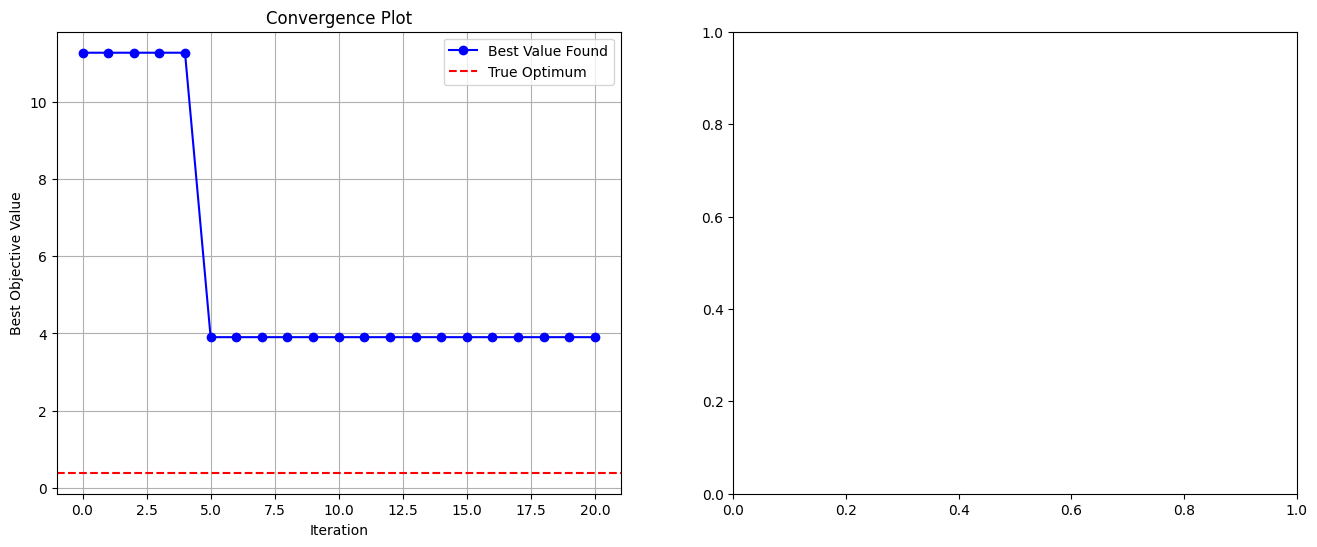

In [18]:
import torch
import torch.nn as nn
import math
import warnings
from botorch.models.model import Model
from botorch.posteriors.posterior import Posterior
from botorch.acquisition import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.test_functions import Branin
from botorch.sampling import IIDNormalSampler
from botorch.sampling.get_sampler import GetSampler
from scipy.stats import t

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

# Set default tensor type
torch.set_default_dtype(torch.float64)

# --- 1. Kernel Function (Required by TPRTFullBatch) ---
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the Radial Basis Function (RBF) kernel between two sets of points.
    """
    if not isinstance(lengthscale, torch.Tensor):
        lengthscale = torch.tensor(lengthscale, device=X1.device, dtype=X1.dtype)
    if not isinstance(variance, torch.Tensor):
        variance = torch.tensor(variance, device=X1.device, dtype=X1.dtype)

    X1_ = X1 / lengthscale
    X2_ = X2 / lengthscale
    dist_sq = torch.cdist(X1_, X2_, p=2).pow(2)
    return variance * torch.exp(-0.5 * dist_sq)

# --- 2. User-Provided TPRTFullBatch Class ---
class TPRTFullBatch:
    """
    Implementation of the full (non-sparse) Student-t Process regression model.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        self.X = X
        self.y = y.view(-1, 1)
        self.N, self.D = X.shape
        self.device = X.device
        self.dtype = X.dtype

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=self.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=self.dtype)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=self.dtype)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=self.dtype)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=self.dtype)))

        self.m_f = torch.zeros(self.N, 1, dtype=self.dtype, device=self.device)
        self.L_f = torch.eye(self.N, dtype=self.dtype, device=self.device)
        self.alpha_r = torch.tensor(1.0, dtype=self.dtype, device=self.device)
        self.beta_r = torch.tensor(1.0, dtype=self.dtype, device=self.device)
        self.alpha_lambda = torch.ones(self.N, 1, dtype=self.dtype, device=self.device)
        self.beta_lambda = torch.ones(self.N, 1, dtype=self.dtype, device=self.device)

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma_sq": torch.exp(self.log_likelihood_sigma_sq),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }

    def _update_q_lambda(self, params):
        S_f = self.L_f @ self.L_f.T
        var_f = S_f.diag().unsqueeze(1)
        expected_f_mean = self.m_f
        self.alpha_lambda = params['nu_e'] / 2.0 + 0.5
        expected_sq_error = (self.y - expected_f_mean).pow(2) + var_f
        self.beta_lambda = params['nu_e'] / 2.0 + (1.0 / (2.0 * params['sigma_sq'])) * expected_sq_error

    def _update_q_r(self, params, Lxx):
        S_f = self.L_f @ self.L_f.T
        trace_term = torch.trace(torch.cholesky_solve(S_f, Lxx))
        mean_term = self.m_f.T @ torch.cholesky_solve(self.m_f, Lxx)
        expected_f_quadratic_form = trace_term + mean_term
        self.alpha_r = params['nu_f'] / 2.0 + self.N / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_f_quadratic_form.squeeze()

    def _update_q_f(self, params, Lxx):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = expected_r * Kxx_inv + torch.diag(expected_lambda.squeeze() / params['sigma_sq'])
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N, device=self.device), L_f_inv, upper=False)[0]
        temp_vec = (expected_lambda / params['sigma_sq']) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, params, Lxx):
        self._update_q_lambda(params)
        self._update_q_r(params, Lxx)
        self._update_q_f(params, Lxx)

    def _e_step(self, cavi_max_iter=10, cavi_tol=1e-5):
        with torch.no_grad():
            params = self._get_hyperparams()
            Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)
            for _ in range(cavi_max_iter):
                m_f_prev = self.m_f.clone()
                self._cavi_step(params, Lxx)
                if torch.norm(self.m_f - m_f_prev) / (torch.norm(m_f_prev) + 1e-8) < cavi_tol:
                    break

    def _m_step(self, optimizer):
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, cavi_tol=1e-5, lr=0.01, verbose=False):
        params_to_optimize = [p for p in self.__dict__.values() if isinstance(p, nn.Parameter)]
        if not params_to_optimize:
            return

        optimizer = torch.optim.Adam(params_to_optimize, lr=lr)

        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter, cavi_tol=cavi_tol)
            self._m_step(optimizer)

    def _calculate_elbo(self):
        params = self._get_hyperparams()
        Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        Kxx += torch.eye(self.N, device=self.device) * 1e-6
        Lxx = torch.linalg.cholesky(Kxx)
        S_f = self.L_f @ self.L_f.T
        E_q_f = self.m_f
        Var_q_f = S_f.diag().unsqueeze(1)
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        e_log_lik = -0.5 * self.N * math.log(2 * math.pi) - 0.5 * self.N * torch.log(params['sigma_sq']) + \
                      0.5 * torch.sum(E_log_lambda) - \
                      0.5 / params['sigma_sq'] * torch.sum(E_lambda * expected_sq_error)
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        log_q_f = -torch.sum(torch.log(torch.diag(self.L_f)))
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r
        trace_term = torch.trace(torch.cholesky_solve(S_f, Lxx))
        quad_form_term = self.m_f.T @ torch.cholesky_solve(self.m_f, Lxx)
        E_quad_form_f = trace_term + quad_form_term
        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * log_det_Kxx + 0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        E_log_p_r = p_alpha_r * torch.log(p_beta_r) - torch.lgamma(p_alpha_r) + \
                    (p_alpha_r - 1) * E_log_r - p_beta_r * E_r
        kl_f_r_grouped = (log_q_f + log_q_r) - (E_log_p_f_r + E_log_p_r)
        p_alpha_lambda, p_beta_lambda = params['nu_e'] / 2.0, params['nu_e'] / 2.0
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(p_alpha_lambda) - p_alpha_lambda * torch.log(p_beta_lambda)) - \
                    (self.alpha_lambda - p_alpha_lambda) * E_log_lambda + \
                    (self.beta_lambda - p_beta_lambda) * E_lambda
        kl_lambda_sum = torch.sum(kl_lambda)
        return e_log_lik - kl_f_r_grouped - kl_lambda_sum

    def predict(self, X_test):
        # Removed `with torch.no_grad():` to allow for gradient computation
        params = self._get_hyperparams()
        K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
        K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()
        Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        Kxx += torch.eye(self.N, device=self.device) * 1e-6
        Lxx = torch.linalg.cholesky(Kxx)

        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        pred_mean = K_star_x @ Kxx_inv_mf

        S_f = self.L_f @ self.L_f.T
        Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)

        var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()

        E_inv_r = self.beta_r / (self.alpha_r - 1.0).clamp(min=1e-6)
        var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

        pred_var = var_from_prior + var_from_q_f
        pred_nu = 2 * self.alpha_r

        return pred_mean, pred_var.clamp(min=1e-9).unsqueeze(1), pred_nu

# --- 3. Custom Differentiable Inverse CDF for Student-T Distribution ---
class StudentT_PPF(torch.autograd.Function):
    @staticmethod
    def forward(ctx, q, df, loc, scale):
        # Detach tensors and move to numpy for scipy calculation
        q_np = q.detach().cpu().numpy()
        df_np = df.detach().cpu().numpy() if torch.is_tensor(df) else df
        loc_np = loc.detach().cpu().numpy()
        scale_np = scale.detach().cpu().numpy()

        # Scipy's percent point function (inverse of cdf)
        result_np = t.ppf(q=q_np, df=df_np, loc=loc_np, scale=scale_np)

        # Convert back to a tensor with the correct device and dtype
        result = torch.from_numpy(result_np).to(loc)

        # Save tensors for backward pass
        ctx.save_for_backward(result, loc, scale)

        return result

    @staticmethod
    def backward(ctx, grad_output):
        """
        Compute gradients for loc and scale.
        y = loc + scale * ppf_standard(q, df)
        dy/dloc = 1
        dy/dscale = ppf_standard(q, df) = (y - loc) / scale
        """
        y, loc, scale = ctx.saved_tensors

        # Gradients for q and df are not needed
        grad_q = grad_df = None

        # Gradient for loc
        grad_loc = grad_output.clone()

        # Gradient for scale
        ppf_standard = (y - loc) / scale
        grad_scale = grad_output * ppf_standard

        return grad_q, grad_df, grad_loc, grad_scale

# --- 4. Custom Posterior Class for the Student-T Distribution ---
class TPRTPosterior(Posterior):
    def __init__(self, mean, variance, df):
        super().__init__()
        self.mean = mean
        self.variance = variance
        self.df = df
        # Note: self.student_t is mainly for the rsample method, not rsample_from_base_samples
        self.student_t = torch.distributions.StudentT(df=self.df, loc=self.mean, scale=self.variance.sqrt())
        self._normal_dist = torch.distributions.Normal(0.0, 1.0)

    @property
    def device(self):
        return self.mean.device

    @property
    def dtype(self):
        return self.mean.dtype

    @property
    def event_shape(self) -> torch.Size:
        return self.mean.shape[-1:]

    @property
    def base_sample_shape(self) -> torch.Size:
        return self.mean.shape

    @property
    def batch_range(self) -> tuple[int, int]:
        return (0, self.mean.ndim - len(self.event_shape))

    def rsample(self, sample_shape=torch.Size()):
        return self.student_t.rsample(sample_shape)

    def rsample_from_base_samples(
        self, sample_shape: torch.Size, base_samples: torch.Tensor
    ) -> torch.Tensor:
        """
        Transforms samples from a standard normal base distribution to samples from the
        Student-T posterior distribution via our custom differentiable inverse-CDF function.
        """
        uniform_samples = self._normal_dist.cdf(base_samples)

        # Use the custom autograd function to get differentiable samples
        t_samples = StudentT_PPF.apply(
            uniform_samples, self.df, self.mean, self.variance.sqrt()
        )
        return t_samples


# Register a custom sampler for our custom posterior class
@GetSampler.register(TPRTPosterior)
def _get_tprt_sampler(
    posterior: TPRTPosterior, sample_shape: torch.Size, seed: int | None = None
):
    return IIDNormalSampler(sample_shape=sample_shape, seed=seed)

# --- 5. BoTorch Wrapper Model ---
class TPRTBoTorchModel(Model):
    def __init__(self, train_X, train_Y, **kwargs):
        super().__init__()
        self.train_X = train_X
        self.train_Y = train_Y
        self.model = TPRTFullBatch(X=train_X, y=train_Y, **kwargs)
        self.model.fit(max_iter_global=50, cavi_max_iter=15, lr=0.05)

    @property
    def num_outputs(self) -> int:
        return self.train_Y.shape[-1]

    def posterior(self, X: torch.Tensor, observation_noise: bool = False, **kwargs) -> Posterior:
        X_reshaped = X.view(-1, self.train_X.shape[-1])
        mean, var, df = self.model.predict(X_reshaped)
        target_shape = X.shape[:-1] + torch.Size([self.num_outputs])
        mean = mean.view(target_shape)
        var = var.view(target_shape)
        return TPRTPosterior(mean=mean, variance=var, df=df)

    def condition_on_observations(self, X, Y, **kwargs):
        return TPRTBoTorchModel(X, Y)

# --- 6. Optimization Loop ---
def run_bo_loop(model, bounds, objective_func, n_iterations=10):
    """Runs the Bayesian optimization loop."""
    all_x = [model.train_X]
    all_y = [model.train_Y]
    best_values = [model.train_Y.min().item()]

    print(f"Initial best value: {best_values[-1]:.4f}")

    for i in range(n_iterations):
        acq_function = qLogNoisyExpectedImprovement(
            model=model,
            X_baseline=model.train_X,
        )

        candidate, _ = optimize_acqf(
            acq_function=acq_function,
            bounds=bounds,
            q=1,
            num_restarts=10,
            raw_samples=512,
        )

        new_x = candidate.detach()
        new_y = objective_func(new_x)

        train_X = torch.cat([model.train_X, new_x])
        train_Y = torch.cat([model.train_Y, new_y])

        model = model.condition_on_observations(train_X, train_Y)

        all_x.append(new_x)
        all_y.append(new_y)
        best_values.append(train_Y.min().item())

        print(
            f"Iteration {i+1}/{n_iterations} | "
            f"Best value found: {best_values[-1]:.4f}"
        )

    return model, torch.cat(all_x), torch.cat(all_y), best_values

# --- 7. Main Execution ---
if __name__ == "__main__":
    torch.manual_seed(42)

    problem = Branin()
    bounds = problem.bounds
    objective_func = lambda x: problem(x).unsqueeze(-1)

    N_INIT = 10
    train_X = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(N_INIT, problem.dim)
    train_Y = objective_func(train_X)

    model = TPRTBoTorchModel(train_X, train_Y)

    N_ITERATIONS = 20
    final_model, all_X, all_Y, best_values = run_bo_loop(
        model, bounds, objective_func, n_iterations=N_ITERATIONS
    )

    # --- 8. Results ---
    final_best_idx = all_Y.argmin()
    final_best_X = all_X[final_best_idx]
    final_best_Y = all_Y[final_best_idx]

    print("-" * 50)
    print("Optimization finished.")
    print(f"Best point found: {final_best_X.numpy().round(4)}")
    print(f"Best value found: {final_best_Y.item():.4f}")
    print(f"True optimal value: {problem.optimal_value:.4f}")
    print("-" * 50)

    # --- 9. Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot(range(N_ITERATIONS + 1), best_values, 'b-', marker='o', label='Best Value Found')
    ax1.axhline(y=problem.optimal_value, color='r', linestyle='--', label='True Optimum')
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Best Objective Value")
    ax1.set_title("Convergence Plot")
    ax1.legend()
    ax1.grid(True)

    contour = ax2.contourf(problem.x_mesh, problem.y_mesh, problem.f_mesh, 15, cmap=plt.cm.viridis)
    fig.colorbar(contour, ax=ax2, label="Objective Value")

    ax2.plot(train_X[:, 0].numpy(), train_X[:, 1].numpy(), 'kx', markersize=10, markeredgewidth=2, label='Initial Points')
    evaluated_X = all_X[N_INIT:]
    ax2.plot(evaluated_X[:, 0].numpy(), evaluated_X[:, 1].numpy(), 'r.', markersize=8, label='Evaluated Points')
    ax2.plot(final_best_X[0].numpy(), final_best_X[1].numpy(), 'y*', markersize=15, markeredgewidth=1.5, markeredgecolor='black', label='Final Best Point')

    ax2.set_xlabel("X1")
    ax2.set_ylabel("X2")
    ax2.set_title("Evaluated Points on Branin Function")
    ax2.legend(loc='best')
    ax2.set_xlim(bounds[0, 0].item(), bounds[1, 0].item())
    ax2.set_ylim(bounds[0, 1].item(), bounds[1, 1].item())

    plt.tight_layout()
    plt.show()


In [19]:
all_Y

tensor([[195.8797],
        [132.5881],
        [ 22.5456],
        [133.5280],
        [141.0439],
        [ 31.6038],
        [148.4201],
        [ 35.0818],
        [ 11.2621],
        [ 31.9910],
        [303.9433],
        [ 50.1885],
        [171.6130],
        [ 87.3716],
        [  3.9045],
        [ 10.9609],
        [100.7806],
        [308.1291],
        [  4.3939],
        [ 17.5083],
        [308.1291],
        [210.2519],
        [308.1291],
        [308.1291],
        [308.1291],
        [308.1291],
        [308.1291],
        [ 16.1909],
        [308.1291],
        [308.1291]])